In [ ]:
# Step 1:  Import Libraries

In [1]:
# For handling arrays and numerical operations
import numpy as np
# For data manipulation
import pandas as pd
# For interacting with the operating system (e.g., for file handling)
import os
# For building and training deep learning models
import tensorflow as tf
# For plotting data and results
import matplotlib.pyplot as plt
# For more advanced plotting (heatmaps, etc.)
import seaborn as sns
# For image processing
from tensorflow.keras.preprocessing import image
# For creating sequential models
from tensorflow.keras.models import Sequential
# Common layers used for CNN
from keras.layers import Dense, Conv2D, Flatten, Input, Dropout, MaxPooling2D
# TensorFlow helper modules
from tensorflow.keras import datasets, layers, models
# For confusion matrix calculations
from tensorflow.math import confusion_matrix
# For splitting dataset into training and testing sets
from sklearn.model_selection import train_test_split
# For encoding categorical labels
from sklearn.preprocessing import LabelEncoder
# For converting labels to categorical format
from tensorflow.keras.utils import to_categorical
# Pretrained models for transfer learning
from tensorflow.keras.applications import EfficientNetB4, Xception, ResNet50
# For model building and combining layers
from tensorflow.keras.layers import GlobalAveragePooling2D, concatenate
# For more flexible model definition
from tensorflow.keras.models import Model
# For callbacks during training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# For loading saved models
from tensorflow.keras.models import load_model
# For image augmentation and preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# For random operations
import random
# For working with file paths
import os
# For reading and manipulating images
import cv2
# For handling warnings
import warnings
# Disabling warnings for cleaner output
warnings.filterwarnings('ignore')

In [3]:
# Step 2: Exploring the Dataset Directory Structure

In [4]:
# Import the os module to interact with the operating system
import os
# Traverse through the directory to list all files
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Glass Dection in image classification in CNN'):
    for filename in filenames:
        # Print the full path of each file
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-7-column-1.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-1-column-7.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-7-column-8.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-1-column-3.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-1-column-5.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-7-column-7.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-1-column-4.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-7-column-2.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-7-column-10.jpg
/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test/row-1-column-2.jpg
/content/drive/MyDrive/Glass 

In [5]:
# Step 3: Preparing the Dataset for Training and Validation

In [6]:
# Define directory paths for training and validation data
train_dir = "/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/train"  # Path to training images
val_dir = "/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/validate"  # Path to validation images

In [8]:
# Step 4: Defining Subdirectory Paths for Each Class

In [9]:
# Define paths for the 'glasses' and 'no_glasses' directories in training and validation datasets
glasses_dir = os.path.join(train_dir, 'glasses')
# Path to training images with glasses
no_glasses_dir = os.path.join(train_dir, 'noglasses')  # Path to training images without glasses
val_glasses_dir = os.path.join(val_dir, 'glasses')
# Path to validation images with glasses
val_no_glasses_dir = os.path.join(val_dir, 'noglasses')  # Path to validation images without      glasses

In [ ]:
# Step 5:  Creating Lists of Image File Paths

In [11]:
# Create lists of image paths for each category (glasses and no-glasses) from training and validation directories
glasses_images = [os.path.join(glasses_dir, img) for img in os.listdir(glasses_dir)]
# List of full paths for training images with glasses
no_glasses_images = [os.path.join(no_glasses_dir, img) for img in os.listdir(no_glasses_dir)]
# List of full paths for training images without glasses
val_glasses_images = [os.path.join(val_glasses_dir, img) for img in os.listdir(val_glasses_dir)]
# List of full paths for validation images with glasses
val_no_glasses_images = [os.path.join(val_no_glasses_dir, img) for img in
os.listdir(val_no_glasses_dir)]
# List of full paths for validation images without glasses

In [ ]:
# Step 6:  Creating Labeled DataFrames for Training and Validation

In [12]:
# Create labeled DataFrames for training images
glasses_df = pd.DataFrame({'image_path': glasses_images, 'label': "Yes"})
# DataFrame for training images with glasses
no_glasses_df = pd.DataFrame({'image_path': no_glasses_images, 'label': "No"})
# DataFrame for training images without glasses
# Create labeled DataFrames for validation images
val_glasses_df = pd.DataFrame({'image_path': val_glasses_images, 'label': "Yes"})
# DataFrame for validation images with glasses
val_no_glasses_df = pd.DataFrame({'image_path': val_no_glasses_images, 'label': "No"})
# DataFrame for validation images without glasses

In [ ]:
# Step 7: Concatenating Labeled DataFrames for Final Training and Validation Sets

In [13]:
train = pd.concat([glasses_df, no_glasses_df], ignore_index=True)
# Combine both glasses and no-glasses DataFrames into a single training DataFrame
val = pd.concat([val_glasses_df, val_no_glasses_df], ignore_index=True)
# Combine both glasses and no-glasses DataFrames into a single validation DataFrame

In [ ]:
# Step 8: Shuffling the Data

In [16]:
train = train.sample(frac=1).reset_index(drop=True)
# Shuffle the training dataset randomly and reset the index
val = val.sample(frac=1).reset_index(drop=True)
# Shuffle the validation dataset randomly and reset the index
train.head(10)
# Display the first 10 rows of the training dataset to inspect image paths and corresponding labels
val.head(10)
# Display the first 10 rows of the validation dataset to inspect image paths and corresponding labels
# Checking Dataset Dimensions
train.shape
# Returns the shape of the training dataset in the format (number of samples, number of columns)
val.shape
# Returns the shape of the validation dataset in the format (number of samples, number of columns)

(40, 2)

In [ ]:
# Step 9: Visualizing Sample Images from Training Data

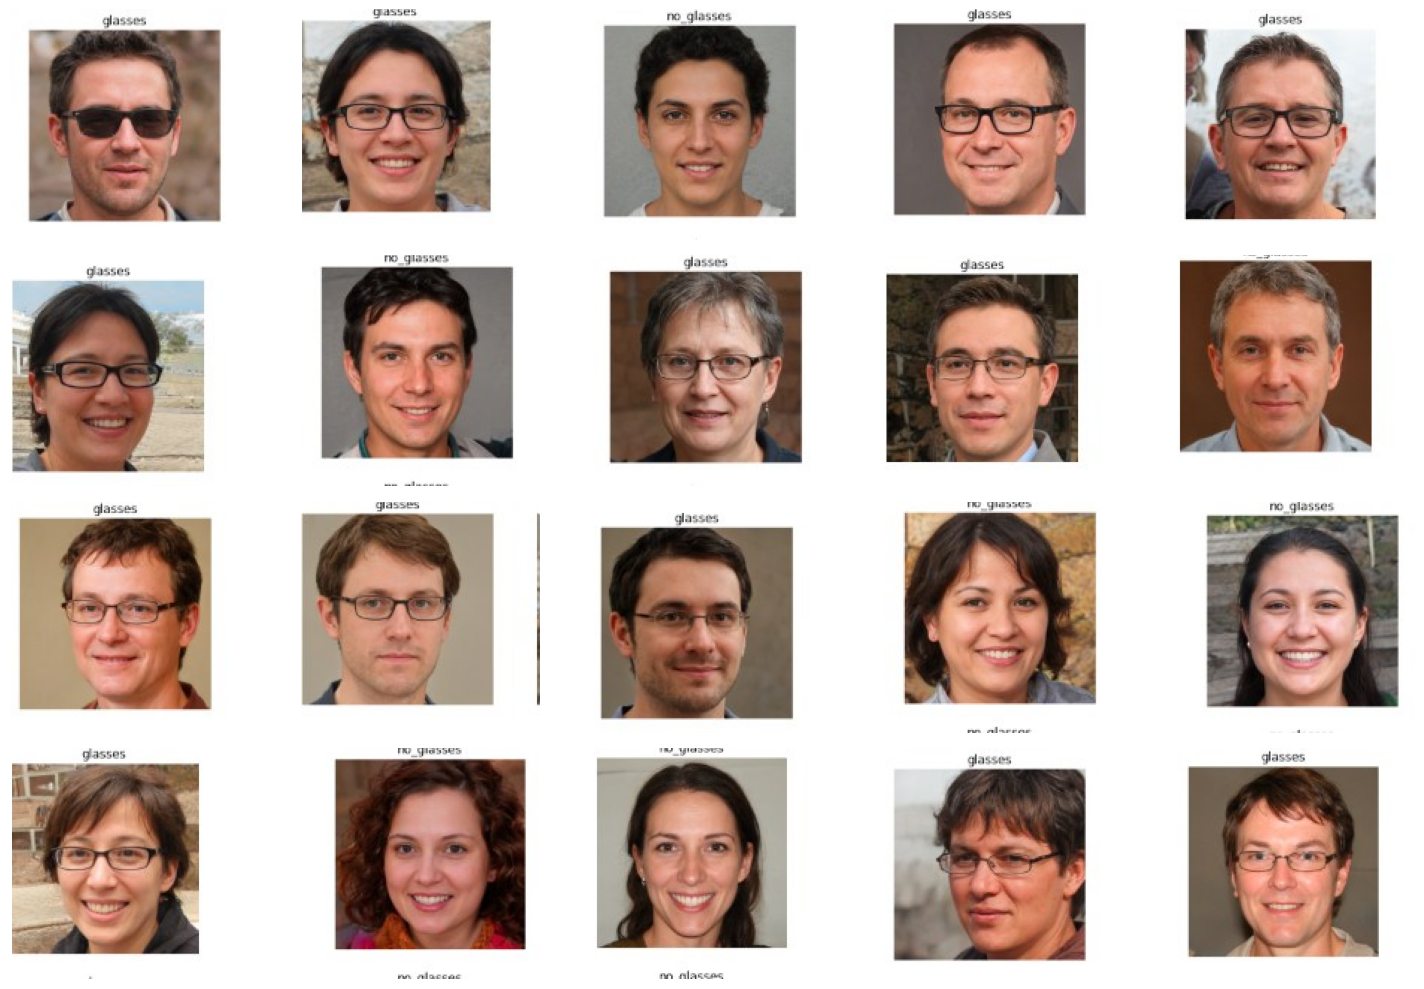

In [20]:
plt.figure(figsize=(15, 10))  # Set the overall figure size
for i in range(20):
  # Create a grid of 4 rows and 5 columns for subplots
  plt.subplot(4, 5, i + 1)
  # Get the image path from the training dataframe
  img_path = train.loc[i, "image_path"]
  # Read the image using OpenCV (BGR format)
  img = cv2.imread(img_path)
  # Convert BGR to RGB for correct color display
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.imshow(img)
  plt.axis('off')

plt.tight_layout()
# Show the image
# Hide the axis for a cleaner look
# Automatically adjust subplot parameters for better spacing
plt.show()

In [ ]:
# Step 10: Image Augmentation for Training Data

In [23]:
train_datagen = ImageDataGenerator(
rotation_range=20,
# Display the grid of images
# Randomly rotate images by up to 20 degrees
width_shift_range=0.1,
height_shift_range=0.1,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,
fill_mode='nearest',
rescale=1.0/255.0
)

In [ ]:
# Step 11: Loading and Augmenting Training Data

In [24]:
augmented_images = train_datagen.flow_from_dataframe(
train,
x_col='image_path',
y_col='label',
target_size=(150, 150),
batch_size=32,
class_mode='binary'
)

Found 104 validated image filenames belonging to 2 classes.


In [ ]:
# Step 12: Loading and Rescaling Validation Data

In [27]:
# Only rescaling the images to the range [0, 1]
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
# Load validation data using the
val_generator = val_datagen.flow_from_dataframe(
val,
x_col='image_path',
y_col='label',
target_size=(150, 150),
batch_size=32,
class_mode='binary'
)

Found 40 validated image filenames belonging to 2 classes.


In [ ]:
# Step 13: Visualizing Augmented Images

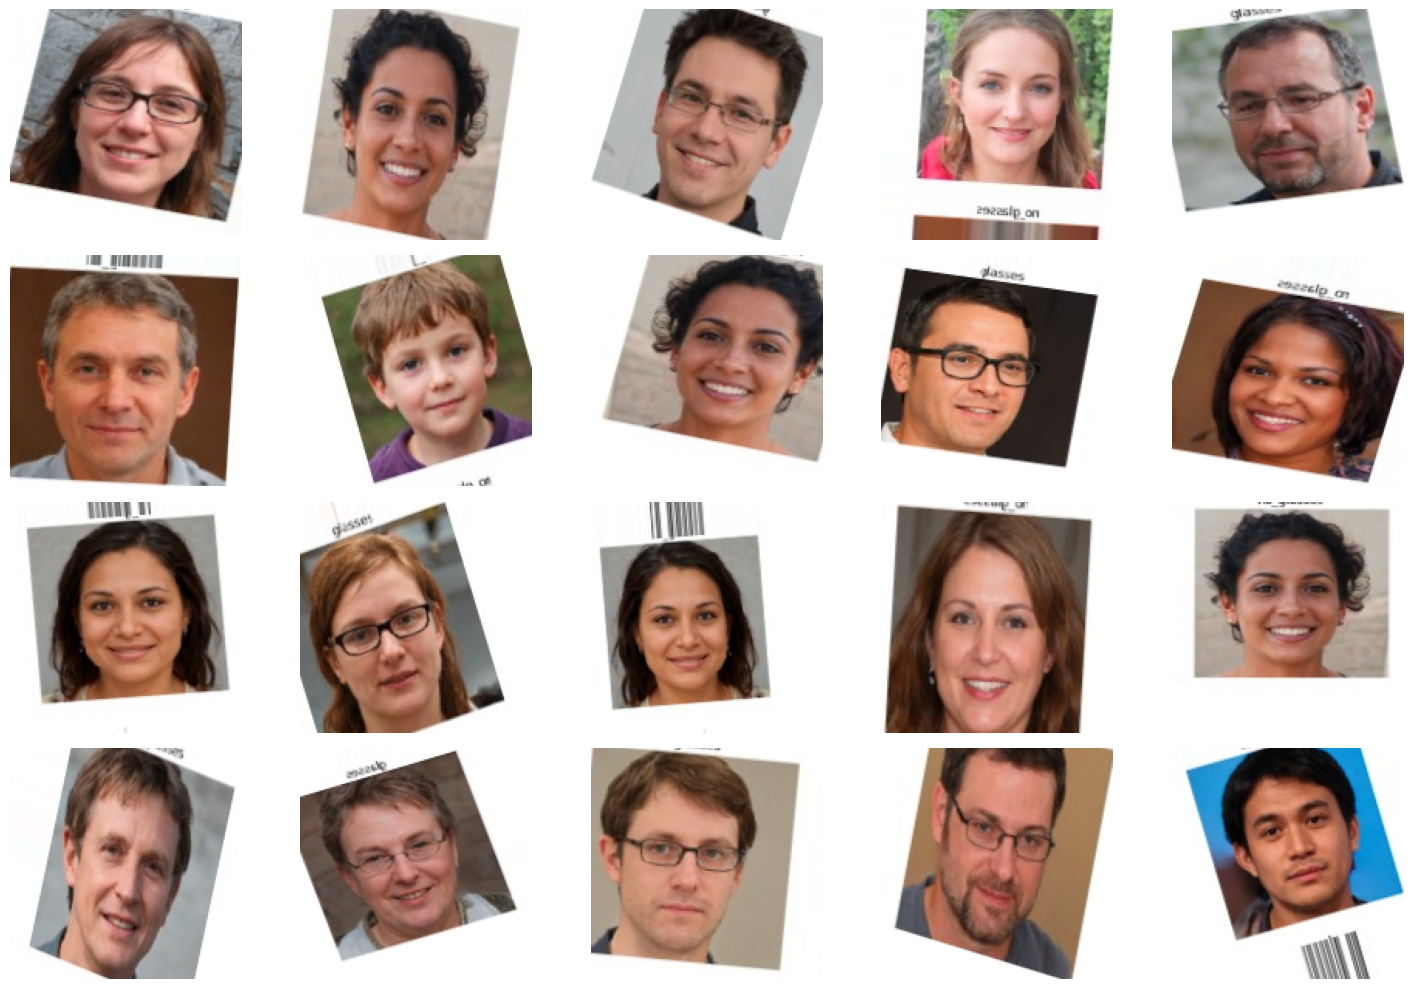

In [29]:
plt.figure(figsize=(15, 10))
for i in range(20):
  img, label = next(augmented_images)
  plt.subplot(4, 5, i + 1)
  plt.imshow(img[0])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Step 14: Defining the CNN Model for Glasses Detection

In [30]:
# Initialize a Sequential model (a linear stack of layers)
model = Sequential([
# Convolutional layer with 16 filters, 3x3 kernel, ReLU activation, input size of 150x150x3 (RGB images)
Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 3)),
# Max pooling layer to reduce spatial dimensions by a factor of 2x2
MaxPooling2D(2, 2),
# Another convolutional layer with 32 filters and ReLU activation
Conv2D(32, (3, 3), activation='relu'),
MaxPooling2D(2, 2),  # Max pooling layer
# A convolutional layer with 128 filters
Conv2D(64, (3, 3),
activation='relu'),
MaxPooling2D(2, 2),
# A convolutional layer with 128 filters
Conv2D(128, (3, 3),
activation='relu'),
MaxPooling2D(2, 2),
# Max pooling layer
# Max pooling layer
# Flatten the 3D output of the previous layer into 1D (to connect to dense layers)
Flatten(),
# Fully connected dense layer with 128 units and ReLU activation
Dense(128, activation='relu'),
Dropout(0.2),
# Dropout regularization to prevent overfitting (20% dropout)
# Output layer with a single neuron and sigmoid activation (binary classification)
Dense(1, activation='sigmoid')
])
# Print the summary of the model, including the architecture and parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 900,513 (3.44 MB)

 Trainable params: 900,513 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 15: Compiling and Training the Model with Callbacks

In [34]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Compile the model using Adam optimizer, binary crossentropy loss for binary classification, and track accuracy during training
# Define the checkpoint to save the best model based on validation accuracy
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', verbose=1,
save_best_only=True, mode='max')
# early_stopping = EarlyStopping(monitor='val_accuracy', patience=10,
# restore_best_weights=True)  # (Optional) Early stopping can be used to halt training if validation accuracy doesn't improve
# Train the model using the training data (augmented_images) and validation data (val_generator)
history = model.fit(
augmented_images,
validation_data=val_generator,
epochs=150,
batch_size=32,
callbacks=[checkpoint]
# Augmented training data
# Validation data generator
# Set the number of epochs to train
# Set the batch size for training
# Include checkpoint callback to save the best model based on validation accuracy
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.4452 - loss: 0.7166
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.4485 - loss: 0.7158 - val_accuracy: 0.5000 - val_loss: 0.7074
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.4459 - loss: 0.7122
Epoch 2: val_accuracy did not improve from 0.50000
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 987ms/step - accuracy: 0.4491 - loss: 0.7095 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.4584 - loss: 0.6984
Epoch 3: val_accuracy did not improve from 0.50000
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4705 - loss: 0.6977 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.4785 - loss: 0.6924
Epoch 4: val_accuracy did not improve from 0.50000
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 700ms/step - accuracy: 0.4847 - loss: 0.6919 - val_ac

In [35]:
# Step 16: Plotting Training and Validation Loss/Accuracy

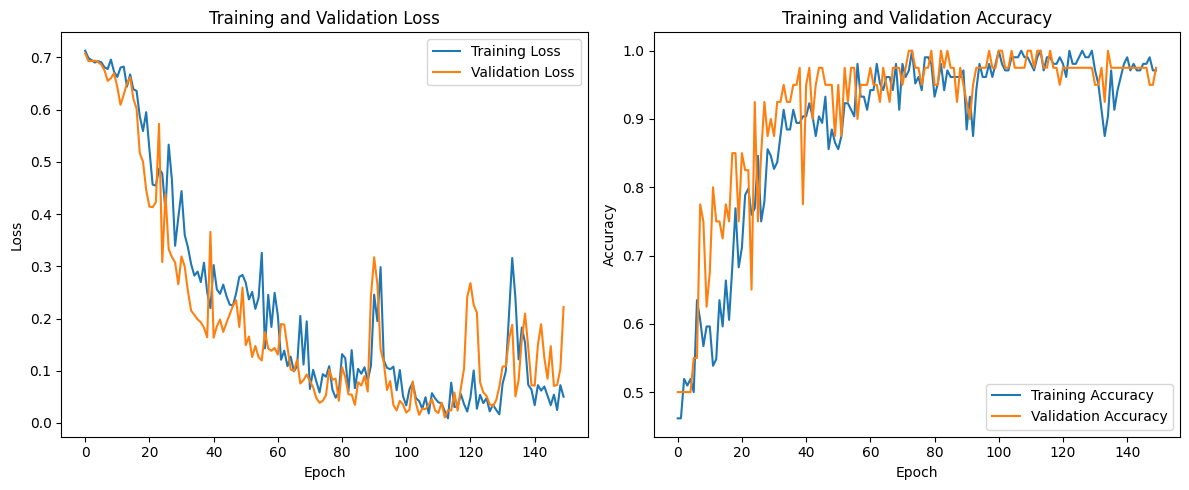

In [36]:
# Plotting the training and validation loss and accuracy over epochs
# Create a figure for the subplots
plt.figure(figsize=(12, 5))
# Subplot for Loss (Training vs Validation Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')  # Title of the plot
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# Subplot for Accuracy (Training vs Validation Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
# Plot training loss
# Plot validation loss
# X-axis label
# Y-axis label
# Display the legend for loss
# Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # Plot validation accuracy
plt.title('Training and Validation Accuracy')  # Title of the plot
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# X-axis label
# Y-axis label
# Display the legend for accuracy
# Adjust layout to prevent overlap
plt.tight_layout()
# Display the plots
plt.show()

In [37]:
# Step 17: Loading the Best Model and Preparing for Evaluation

In [43]:
# Define the directory where the test images are located
test_dir = "/content/drive/MyDrive/Glass Dection in image classification in CNN/Data/test"
# Load the previously saved best model (best model based on validation accuracy)
best_model = load_model('best_model.keras')

In [44]:
# Step 18: Creating a Function to Predict Classes for Test Data

In [47]:
def predict_classes(model, directory):
  images = []  # List to store images
  filenames = []  # List to store image file paths
  for img in os.listdir(directory):
    img_path = os.path.join(directory, img)
    # Construct the full image path
    img = image.load_img(img_path, target_size=(150, 150))  # Load and resize the image
    img = image.img_to_array(img)
    images.append(img)
    filenames.append(img_path)
  images = np.array(images)
  predictions = model.predict(images)
  # Convert image to array
  # Append image to the images list
  # Append image path to the filenames list
  # Convert images list to numpy array for model input
  # Get model predictions for the images
  # Classify based on the probability threshold (0.5 for binary classification)
  predicted_classes = (predictions > 0.5).astype('int')
  # Return filenames and predicted class labels
  return filenames, predicted_classes

In [48]:
# Step 19: Predicting Classes for Test Images

In [49]:
test_image_paths, test_predictions = predict_classes(best_model, test_dir)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


In [50]:
# Step 20: Storing Predictions in a DataFrame

In [51]:
predictions_df = pd.DataFrame({'image_path': test_image_paths, 'predicted_class':
test_predictions.flatten()})

In [52]:
# Step 21: Displaying Predictions DataFrame

In [53]:
print(predictions_df.head())

                                          image_path  predicted_class
0  /content/drive/MyDrive/Glass Dection in image ...                0
1  /content/drive/MyDrive/Glass Dection in image ...                1
2  /content/drive/MyDrive/Glass Dection in image ...                0
3  /content/drive/MyDrive/Glass Dection in image ...                1
4  /content/drive/MyDrive/Glass Dection in image ...                1


In [54]:
# Step 22 : Evaluating Model Performance

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:
[[10  0]
 [ 0 10]]


<Axes: >

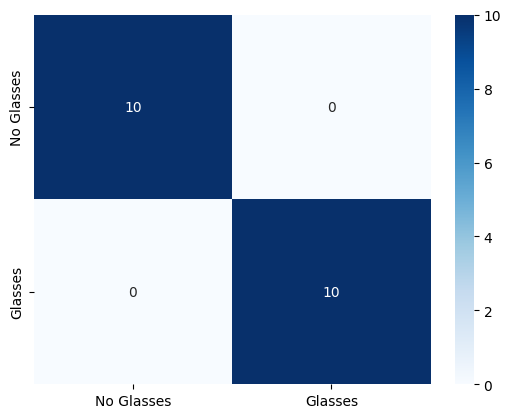

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Flatten the predicted values if needed
predictions_flat = test_predictions.flatten()
# Accuracy
accuracy = accuracy_score(actual_class, predictions_flat)
print(f'Accuracy: {accuracy:.2f}')
# Classification Report
print("Classification Report:")
print(classification_report(actual_class, predictions_flat))
# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(actual_class, predictions_flat)
print(cm)
# Optionally, you can plot the confusion matrix using seaborn
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Glasses', 'Glasses'],
yticklabels=['No Glasses', 'Glasses'])

In [56]:
# Create a list of actual class labels for the test images based on filenames.
# Assuming 'row' followed by a number less than 7 are 'glasses' (1) and 7 or greater are 'no glasses' (0)
actual_class = []
for filename in os.listdir(test_dir):
    row_number = int(filename.split('-')[1])
    if row_number < 7:
        actual_class.append(1) # Glasses
    else:
        actual_class.append(0) # No Glasses

# Convert the list to a numpy array
actual_class = np.array(actual_class)

# Now the actual_class variable is defined and can be used for evaluation

In [58]:
# Step 23: Visualizing Predictions

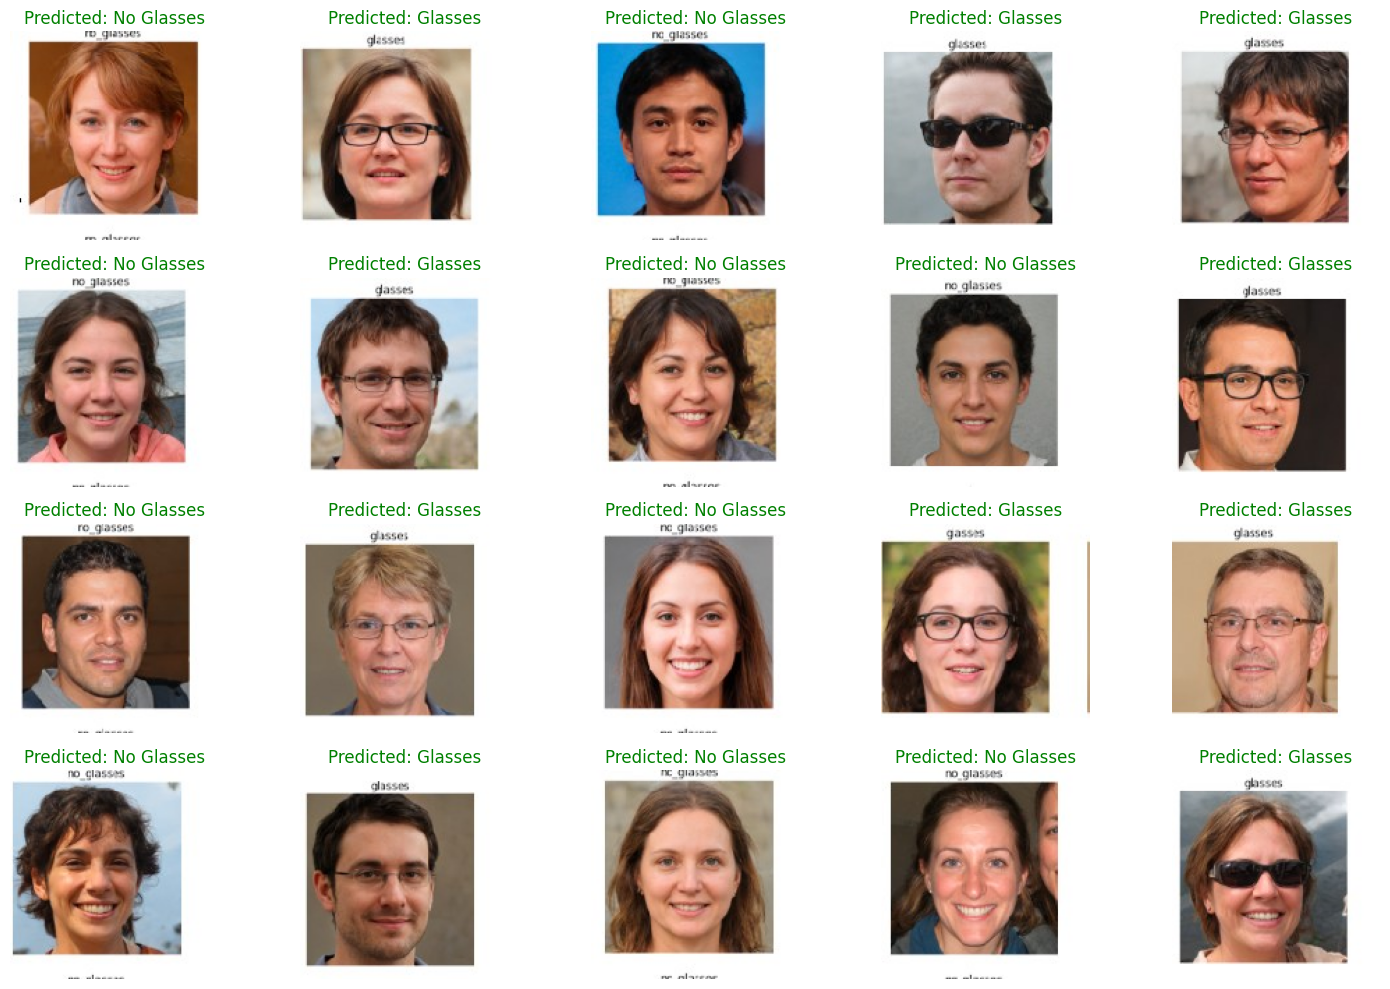

In [61]:
plt.figure(figsize=(15, 10))
for i in range(20):
  # Placing images in a grid (4 rows, 5 columns)
  plt.subplot(4, 5, i + 1)
  # Get image path from the DataFrame
  img_path = predictions_df.loc[i, 'image_path']
  # Load the image with the target size
  # Setting the figure size for the plot
  # Looping through the first 20 images
  img = image.load_img(img_path, target_size=(150, 150))
  # Convert image to an array and normalize the pixel values
  img = image.img_to_array(img)/ 255.0
  plt.imshow(img)
  # Display the image
  predicted = predictions_df.loc[i, 'predicted_class']  # Get predicted class from DataFrame
  actual = actual_class[i]
  # Get actual class from the list
  # Set the title color based on the prediction correctness
  color = 'green' if predicted == actual else 'red'
  # Title with the predicted class
  plt.title(f"Predicted: {'Glasses' if predicted == 1 else 'No Glasses'}", color=color)
  plt.axis('off')
# Hide the axis
plt.tight_layout()
plt.show()
# Adjust the layout of the subplots
# Display the plot

In [62]:
# Step 23: Generating and Visualizing Confusion Matrix

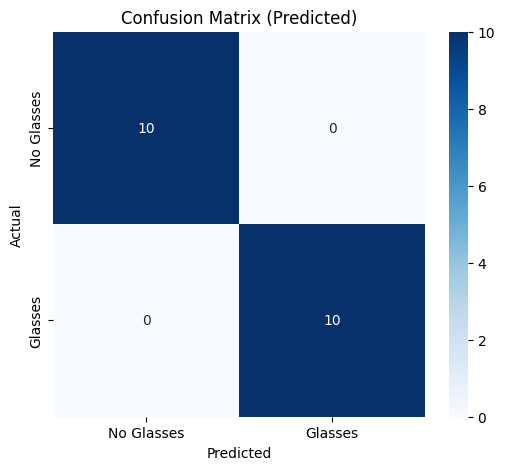

In [63]:
# Converting predicted classes from the predictions dataframe to a list
predicted_classes = predictions_df['predicted_class'].tolist()
# Generating the confusion matrix using sklearn's confusion_matrix function
conf_matrix = confusion_matrix(actual_class, predicted_classes)
# Creating a figure for the heatmap
plt.figure(figsize=(6, 5))
# Plotting the confusion matrix using seaborn's heatmap function
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g',
xticklabels=['No Glasses', 'Glasses'],  # Labels for predicted classes
yticklabels=['No Glasses', 'Glasses'])  # Labels for actual classes
# Adding labels and title to the plot
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Predicted)')
# Displaying the plot
plt.show()

In [64]:
# Step 24 : Saving the best model

In [66]:
best_model=load_model('best_model.keras')